In [ ]:
import tqdm 
import json
import pandas as pd

import glob

import json_repair

main_dir = "/chistera/CaseStudyOutputs/russia_ukraine_war" 
db_names = ["truthsocial_ukraine_russia", "twitter_ukraine_russia"]


In [ ]:
dfs = []
for fpath in glob.glob(main_dir + db_names[0] + "/*.jsonl"):
    dfs.append(pd.read_json(fpath, lines=True))
truthSocial_df = pd.concat(dfs)
del dfs

# Truth Social
truthSocial_df["json_output"] = truthSocial_df["content"].apply(lambda x: json_repair.loads(x) if isinstance(x, str) else x)
truthSocial_df["stance"] = truthSocial_df["json_output"].apply(lambda x: x.get("stance") if isinstance(x, dict) else None)
truthSocial_df["reasoning"] = truthSocial_df["json_output"].apply(lambda x: x.get("reasoning") if isinstance(x, dict) else None)

In [ ]:
def flatten(lst):
    if not isinstance(lst, list):
        return [lst]
    return [item for sublist in lst for item in flatten(sublist)]


In [ ]:
def unpack_stance(stances: list):
    if not stances:
        return "Neutral"
    try:
        stances = flatten(stances)
        stance_text = " ".join(stances).lower()

        if "Pro-Ukraine".lower() in stance_text:
            return "Ukraine"
        elif "Anti-Ukraine".lower() in stance_text:
            return "Russia"
        elif "Pro-Russia".lower() in stance_text:
            return "Russia"
        elif "Anti-Russia".lower() in stance_text:
            return "Ukraine"
        else:
            return "Neutral"
    except Exception as e:
        print(f"Error unpacking stance: {e}")
        print(f"Stances: {stances}")
        return "Neutral"


print("------------Truth Social-------------")
truthSocial_df["leaning"] = truthSocial_df["stance"].apply(unpack_stance)

------------Truth Social-------------
Error unpacking stance: sequence item 1: expected str instance, dict found
Stances: ['Neutral', {'reasoning': 'The post is a link to a source without any evaluative or emotional language. It does not express a clear stance on the Russia-Ukraine conflict or its participants.'}]
Error unpacking stance: sequence item 0: expected str instance, dict found
Stances: [{'reasoning': '/* concise explanation */'}]
Error unpacking stance: sequence item 2: expected str instance, dict found
Stances: ['Anti-Media', 'Neutral', {'reasoning': 'The post criticizes the media for calling the 2020 Presidential Election fraudulent, without providing any evidence or facts to support this claim. The post also highlights the supposed irregularities and lack of approval by state legislatures. However, it does not express any stance toward Russia or Ukraine.'}]


In [ ]:
truthSocial_df["leaning"].value_counts()

leaning
Neutral    42506
Russia     10250
Ukraine     5752
Name: count, dtype: int64

In [ ]:
def safe_json_repair(x):
    if not isinstance(x, str) or len(x.strip()) < 2:
        return None
    try:
        return json_repair.loads(x)
    except Exception as e:
        print(f"Skipping entry due to error: {e}")
        return None

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

truth_social_n_russia = truthSocial_df["leaning"].value_counts().get("Russia", 0)
truth_social_total = truthSocial_df.shape[0]


results = {}


for twitter_ds_path in tqdm.tqdm("/chistera/CaseStudyOutputs/russia_ukraine_war/twitter" + "/*.jsonl", desc="Loading Twitter datasets", leave=False):
    batch_name = twitter_ds_path.split("/")[-1]
    twitter_df = pd.read_json(twitter_ds_path, lines=True)
    twitter_df["json_output"] = twitter_df["content"].apply(lambda x: safe_json_repair(x) if isinstance(x, str) else x)
    twitter_df["stance"] = twitter_df["json_output"].apply(lambda x: x.get("stance") if isinstance(x, dict) else None)
    twitter_df["reasoning"] = twitter_df["json_output"].apply(lambda x: x.get("reasoning") if isinstance(x, dict) else None)
    print("------------Twitter-------------")
    twitter_df["leaning"] = twitter_df["stance"].apply(unpack_stance)


    twitter_n_russia = twitter_df["leaning"].value_counts().get("Russia", 0)
    twitter_total = twitter_df.shape[0]

    count = [truth_social_n_russia, twitter_n_russia]
    nobs: list[int] = [truth_social_total, twitter_total]

    stat, pval = proportions_ztest(count, nobs)
    print(f"Z-statistic: {stat:.4f}, p-value: {pval:.4g}")

    key = batch_name.split("_")[1]   
    results[key] = {
        "batch_name": batch_name,
        "twitter_n_russia": int(twitter_n_russia),
        "twitter_total": int(twitter_total),
        "truth_social_n_russia": int(truth_social_n_russia),
        "truth_social_total": int(truth_social_total),
        "z_statistic": stat,
        "p_value": pval
    }

Loading Twitter datasets:   3%|▎         | 1/30 [00:02<01:03,  2.20s/it]

------------Twitter-------------
Z-statistic: 36.9344, p-value: 1.298e-298


Loading Twitter datasets:   7%|▋         | 2/30 [00:04<00:59,  2.13s/it]

------------Twitter-------------
Z-statistic: 35.4498, p-value: 2.917e-275


Loading Twitter datasets:  10%|█         | 3/30 [00:06<00:57,  2.14s/it]

...

Loading Twitter datasets:  93%|█████████▎| 28/30 [00:56<00:04,  2.05s/it]

------------Twitter-------------
Z-statistic: 35.3376, p-value: 1.553e-273


Loading Twitter datasets:  97%|█████████▋| 29/30 [00:58<00:02,  2.05s/it]

------------Twitter-------------
Error unpacking stance: sequence item 0: expected str instance, dict found
Stances: [{'reasoning': '/* concise explanation */'}, 'To complete this task, follow these steps:\n\n1. Read the given "post" text.\n2. Identify any evaluative, emotional, or moral language that supports or opposes Ukraine, Russia, or their actions in the context of the war.\n3. Determine if the post expresses no clear stance or addresses the conflict directly.\n4. If the post has evaluative language, classify it as "Pro-" or "Anti-" if the stance is clear, or as "Neutral" if it does not clearly express support or opposition.\n5. If the post contains no evaluative']
Z-statistic: 35.6558, p-value: 1.919e-278


------------Twitter-------------
Z-statistic: 34.2011, p-value: 2.327e-256


In [ ]:
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index = results_df.index.astype(int)
results_df.sort_index(inplace=True)
results_df["is_significant"] = results_df["p_value"] < 0.05
results_df

,batch_name,twitter_n_russia,twitter_total,truth_social_n_russia,truth_social_total,z_statistic,p_value,is_significant
1,twitter_1_russia_ukraine_war_posts_outputs_dee...,5912,58508,10250,58508,36.755138,9.624357e-296,True
2,twitter_2_russia_ukraine_war_posts_outputs_dee...,6087,58508,10250,58508,35.113444,4.203001e-270,True
3,twitter_3_russia_ukraine_war_posts_outputs_dee...,6129,58508,10250,58508,34.721838,3.689386e-264,True
4,twitter_4_russia_ukraine_war_posts_outputs_dee...,6085,58508,10250,58508,35.132115,2.180369e-270,True
5,twitter_5_russia_ukraine_war_posts_outputs_dee...,6076,58508,10250,58508,35.216160,1.131433e-271,True
6,twitter_6_russia_ukraine_war_posts_outputs_dee...,5902,58508,10250,58508,36.849442,2.985379e-297,True
7,twitter_7_russia_ukraine_war_posts_outputs_dee...,6063,58508,10250,58508,35.337634,1.552737e-273,True
8,twitter_8_russia_ukraine_war_posts_outputs_dee...,6029,58508,10250,58508,35.655753,1.919032e-278,True
9,twitter_9_russia_ukraine_war_posts_outputs_dee...,6185,58508,10250,58508,34.201121,2.326885e-256,True
10,twitter_10_russia_ukraine_war_posts_outputs_de...,5893,58508,10250,58508,36.934361,1.298453e-298,True


In [ ]:
print(
"""
This means: 

TruthSocial consistently has a significantly higher proportion of Russia-leaning posts than Twitter, even when controlling for sample variability.
"""
)


This means:

TruthSocial consistently has a significantly higher proportion of Russia-leaning posts than Twitter, even when controlling for sample variability.



In [ ]:
import pandas as pd
annotated_data_path = "/chistera/Russia_Ukraine_WarAnnoatedData/project-7-at-2025-08-11-12-32-89c1cd38_MIN.json"

annotated_df = pd.read_json(annotated_data_path, lines=False)
annotated_df.head()

,text,account_id,post_id,source,id,stance,annotator,annotation_id,created_at,updated_at,lead_time
0,@JudieHall9 Because the elitist political clas...,1453787019973431296,1520560118982713344,twitter,601,"{'choices': ['Anti-Ukraine', 'Pro-Russia']}",1,606,2025-07-25 09:42:51.876234+00:00,2025-07-25 09:42:51.876259+00:00,227.833
1,Cannot ignore the political 5th column of Puti...,449588356,1496871285917470720,twitter,602,"{'choices': ['Pro-Ukraine', 'Anti-Russia']}",1,607,2025-07-25 09:44:28.849522+00:00,2025-07-25 09:44:28.849545+00:00,94.410
2,RT @nytimes: Russia’s recognition of two break...,135578944,1496367864219111424,twitter,603,"{'choices': ['Anti-Russia', 'Neutral']}",1,608,2025-07-25 10:27:07.276927+00:00,2025-07-25 10:27:07.276948+00:00,56.019
3,Ukrainian Air Defenses reportedly Active in We...,1457867047334031360,1503791689412091904,twitter,604,Neutral,1,609,2025-07-25 10:27:24.785062+00:00,2025-07-25 10:27:24.785084+00:00,16.426
4,"BREAKING: UK, US Advices Their Citizens To Lea...",1353802167291936768,1498442106104430592,twitter,605,Neutral,1,626,2025-07-25 11:30:31.033160+00:00,2025-07-25 11:30:31.033177+00:00,9.193


In [ ]:
def get_choices(row):
    if isinstance(row["stance"], dict):
        return ", ".join(sorted(row["stance"].get("choices", [])))
    
    return row["stance"]

annotated_df["stances"] = annotated_df.apply(get_choices, axis=1)

In [ ]:
annotated_df["stances"].value_counts()  

stances
Neutral                                   355
Anti-Russia, Pro-Ukraine                   58
Anti-Russia                                58
Anti-Ukraine                               47
Pro-Ukraine                                46
Pro-Russia                                 19
Anti-Ukraine, Pro-Russia                   10
Anti-Ukraine, Pro-Ukraine                   2
Anti-Russia, Neutral                        1
Anti-Russia, Pro-Russia, Pro-Ukraine        1
Neutral, Pro-Ukraine                        1
Anti-Russia, Anti-Ukraine, Pro-Ukraine      1
Anti-Russia, Pro-Russia                     1
Name: count, dtype: int64

In [ ]:
annotated_df["llm_pred"] = None

In [ ]:
truth_social_postid2leaning = {}
for index, row in truthSocial_df.iterrows():
    truth_social_postid2leaning[row["post_id"]] = row["leaning"]


twitter_postid2leaning = {}
for index, row in twitter_df.iterrows():
    twitter_postid2leaning[row["post_id"]] = row["leaning"]

for row in annotated_df.itertuples():
    if row.source == "truth_social":
        annotated_df.at[row.Index, "llm_pred"] = truth_social_postid2leaning.get(row.post_id, "Neutral")
    elif row.source == "twitter":
        annotated_df.at[row.Index, "llm_pred"] = twitter_postid2leaning.get(row.post_id, "Neutral")

In [ ]:
def aggregate_stances(text):
    if "Pro-Russia" in text or "Anti-Ukraine" in text:
        return "Russia"
    elif "Pro-Ukraine" in text or "Anti-Russia" in text:
        return "Ukraine"
    else:
        return "Neutral"

annotated_df["agg_stances"] = annotated_df["stances"].apply(aggregate_stances)

In [ ]:
(annotated_df["llm_pred"] == annotated_df["agg_stances"]).mean()

np.float64(0.625)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(annotated_df["agg_stances"], 
                            annotated_df["llm_pred"]))

              precision    recall  f1-score   support

     Neutral       0.64      0.90      0.75       355
      Russia       0.53      0.40      0.45        81
     Ukraine       0.53      0.15      0.23       164

    accuracy                           0.62       600
   macro avg       0.57      0.48      0.48       600
weighted avg       0.60      0.62      0.57       600



In [ ]:
from sklearn.metrics import classification_report
print("Twitter")
print(classification_report(annotated_df[annotated_df["source"] == "twitter"]["agg_stances"],
                             annotated_df[annotated_df["source"] == "twitter"]["llm_pred"]))

Twitter
              precision    recall  f1-score   support

     Neutral       0.48      0.98      0.64       137
      Russia       0.00      0.00      0.00        24
     Ukraine       0.81      0.09      0.17       139

    accuracy                           0.49       300
   macro avg       0.43      0.36      0.27       300
weighted avg       0.59      0.49      0.37       300



In [ ]:
from sklearn.metrics import classification_report
print("TruthSocial")
print(classification_report(annotated_df[annotated_df["source"] == "truth_social"]["agg_stances"], 
                            annotated_df[annotated_df["source"] == "truth_social"]["llm_pred"]))

TruthSocial
              precision    recall  f1-score   support

     Neutral       0.87      0.85      0.86       218
      Russia       0.55      0.56      0.56        57
     Ukraine       0.38      0.44      0.41        25

    accuracy                           0.76       300
   macro avg       0.60      0.62      0.61       300
weighted avg       0.77      0.76      0.76       300



In [ ]:
annotated_df["agg_stances"].value_counts()

agg_stances
Neutral    355
Ukraine    164
Russia      81
Name: count, dtype: int64

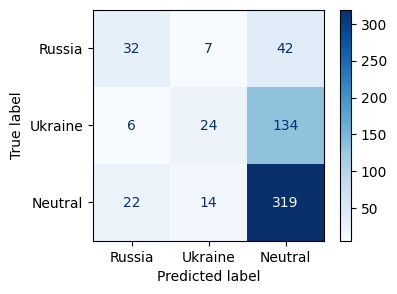

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1,1, figsize=(4, 3))
y_true = annotated_df["agg_stances"]
y_pred = annotated_df["llm_pred"]
cm = confusion_matrix(y_true, y_pred, labels=annotated_df["agg_stances"].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=annotated_df["agg_stances"].unique())
disp.plot(cmap='Blues', ax=ax)

plt.show()

Twitter


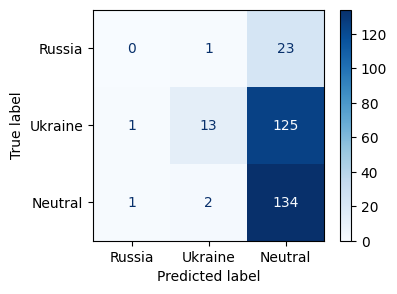

In [ ]:
print("Twitter")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1,1, figsize=(4, 3))
y_true = annotated_df[annotated_df["source"] == "twitter"]["agg_stances"]
y_pred = annotated_df[annotated_df["source"] == "twitter"]["llm_pred"]
cm = confusion_matrix(y_true, y_pred, labels=annotated_df["agg_stances"].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=annotated_df["agg_stances"].unique())
disp.plot(cmap='Blues', ax=ax)

plt.show()


TruthSocial


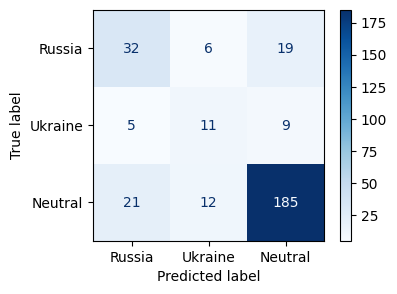

In [ ]:
print("TruthSocial")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1,1, figsize=(4, 3))
y_true = annotated_df[annotated_df["source"] == "truth_social"]["agg_stances"]
y_pred = annotated_df[annotated_df["source"] == "truth_social"]["llm_pred"]
cm = confusion_matrix(y_true, y_pred, labels=annotated_df["agg_stances"].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=annotated_df["agg_stances"].unique())
disp.plot(cmap='Blues', ax=ax)

plt.show()


In [ ]:
pro_russian_samples = annotated_df[annotated_df["llm_pred"] == "Russia"]
sample = pro_russian_samples.sample(1)
print("LLM said, Russia")
print("Annotated as", sample.iloc[0]["agg_stances"])

print("Prediction STATUS:", sample.iloc[0]["llm_pred"] == sample.iloc[0]["agg_stances"])

print("\n\nText:")
print(sample.iloc[0]["text"])

LLM said, Russia
Annotated as Neutral
Prediction STATUS: False


Text:
Mitch McConnell’s push for Republican Senators to vote for Gun Control will be the final straw. Just like he gave away the Debt Ceiling and got NOTHING in return, or handed the Dems a great sound bite and victory with the Infrastructure Bill, which is actually all about the Green New Deal, he is now forcing approval of the FIRST STEP IN TAKING AWAY YOUR GUNS! Republican Senators SHOULD NOT VOTE FOR THIS CAREER ENDING BILL!!!


In [ ]:
temp_df = annotated_df[annotated_df["agg_stances"] == "Ukraine"]
temp_df = temp_df[temp_df["llm_pred"] != "Ukraine"]

sample = temp_df.sample(1)
print("Annotated as", sample.iloc[0]["agg_stances"])
print("LLM said", sample.iloc[0]["llm_pred"])

print("Prediction STATUS:", sample.iloc[0]["llm_pred"] == sample.iloc[0]["agg_stances"])

print("\n\nText:")
print(sample.iloc[0]["text"])

Annotated as Ukraine
LLM said Neutral
Prediction STATUS: False


Text:
Military chaplains accompanied first-graders on their first school day in Kyiv.

The study of the new generation is possible thanks to #Ukrainian defenders – someone’s parents, who couldn’t be with their children on this day.

🎥Oksana Anastasieva 
#StandWithUkraine https://t.co/OyJxm4NGmm


In [ ]:
temp_df = annotated_df[annotated_df["agg_stances"] == "Russia"]
temp_df = temp_df[temp_df["llm_pred"] != "Russia"]

sample = temp_df.sample(1)
print("Annotated as", sample.iloc[0]["agg_stances"])
print("LLM said", sample.iloc[0]["llm_pred"])

print("Prediction STATUS:", sample.iloc[0]["llm_pred"] == sample.iloc[0]["agg_stances"])

print("\n\nText:")
print(sample.iloc[0]["text"])

Annotated as Russia
LLM said Neutral
Prediction STATUS: False


Text:
Fans of every Oceans Eleven movie know the theme: when you rob somebody of illegal money or goods they are hiding, WHO CAN THEY GO COMPLAIN TO?!?! “OFFICER THAT THAT **GUY**…HE STOLE THE 3 BILLION LAUNDERED DOLLARS  I CAN’T ADMIT TO HAVING IN UKRAINE!!!”
